# Step 4 — Von Heijne Signal Peptide Classifier
**LB2 Project · Group 7 · Signal Peptide Prediction**

### Objective
Implement the **von Heijne method** for signal peptide detection using a  
Position-Specific Weight Matrix (PSWM) built from log-odds of amino acid  
frequencies at each position of the cleavage site window.

### Method
1. Extract a **15-position window** (positions **−13 to +2** relative to the cleavage site) from each positive training sequence  
2. Build a **PSWM** using log-odds vs SwissProt background frequencies, with pseudocounts for smoothing  
3. **Score** each protein: slide the PSWM over N-terminal positions 15–100, take the **maximum score**  
4. **5-fold cross-validation**: per fold, select the threshold that maximises F1 on the PR curve; the average threshold is then applied to the blind benchmark set  
5. **Retrain** on the full training set → evaluate on the blind benchmark set  
6. Report: MCC, Precision, Recall, F1, Accuracy + PR curve, ROC curve, PSWM heatmap

### Input files (from previous steps)
| File                        | Description |
|-----------------------------|-------------|
| `filtered_positive.tsv`     | Clustered positive representatives (Step 2) |
| `filtered_negative.tsv`     | Clustered negative representatives (Step 2) |
| `training_with_folds.tsv`   | Training set with label and 5-fold columns |
| `benchmarking_set.tsv`      | Blind benchmark set with label column |
| `positive.fasta` / `negative.fasta` | Source of actual protein sequences (only filtered accessions are used) |

### Output files
| File | Description |
|------|-------------|
| `figures/vh_cv_pr_roc.pdf/.png`     | Cross-validation PR + ROC curves |
| `figures/vh_pswm_heatmap.pdf/.png`  | PSWM log-odds heatmap |
| `figures/vh_benchmark_confusion.pdf/.png` | Benchmark confusion matrix |

**Key note**: Sequences were restricted to the filtered non-redundant set before training and evaluation (Step 2).

---
## Cell 1 — Install dependencies

In [13]:
!pip install -q biopython pandas numpy scikit-learn matplotlib seaborn
print('Done.')

Done.


---
## Cell 2 — Imports and constants

In [14]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import SeqIO
from sklearn.metrics import (
    precision_recall_curve, roc_curve, auc,
    f1_score, accuracy_score, recall_score,
    precision_score, matthews_corrcoef, confusion_matrix
)
import warnings
warnings.filterwarnings('ignore')

os.makedirs('figures', exist_ok=True)
sns.set_theme(style='whitegrid', font_scale=1.1)

# SwissProt background amino acid frequencies (ExPASy release statistics)
SWISSPROT_FREQ = {
    'A': 0.0825, 'C': 0.0138, 'D': 0.0546, 'E': 0.0671, 'F': 0.0386,
    'G': 0.0707, 'H': 0.0227, 'I': 0.0590, 'K': 0.0579, 'L': 0.0964,
    'M': 0.0241, 'N': 0.0406, 'P': 0.0474, 'Q': 0.0393, 'R': 0.0552,
    'S': 0.0665, 'T': 0.0536, 'V': 0.0685, 'W': 0.0110, 'Y': 0.0292
}
AA_LIST = sorted(SWISSPROT_FREQ.keys())  # 20 AAs in alphabetical order
AA_IDX  = {aa: i for i, aa in enumerate(AA_LIST)}

# PSWM window: 13 positions before cleavage site + 2 after = 15 total
WINDOW_BEFORE = 13
WINDOW_AFTER  = 2
WINDOW_SIZE   = WINDOW_BEFORE + WINDOW_AFTER  # 15

# Scoring: search cleavage sites between position 15 and 100 of the N-terminus
MIN_CLEAVAGE = 15
MAX_CLEAVAGE = 100

print(f'Window size       : {WINDOW_SIZE} positions ({-WINDOW_BEFORE} to +{WINDOW_AFTER})')
print(f'Cleavage search   : positions {MIN_CLEAVAGE} to {MAX_CLEAVAGE}')
print(f'Amino acids       : {len(AA_LIST)}')

Window size       : 15 positions (-13 to +2)
Cleavage search   : positions 15 to 100
Amino acids       : 20


---
## Cell 3 — Load filtered metadata + sequences

**Important:** We now load the **clustered filtered** datasets from Step 2 instead of the raw FASTA files.  
This guarantees we only use the exact sequences that went into training and benchmarking.

In [15]:
# Load filtered metadata from Step 2 (these are the clustered representatives)
df_filtered_pos = pd.read_csv('filtered_positive.tsv', sep='\t')
df_filtered_neg = pd.read_csv('filtered_negative.tsv', sep='\t')

print(f'Filtered positive sequences (from Step 2): {len(df_filtered_pos):,}')
print(f'Filtered negative sequences (from Step 2): {len(df_filtered_neg):,}')

# Load sequences from FASTA (but only keep those that appear in the filtered sets)
pos_seqs = {}
for rec in SeqIO.parse('positive.fasta', 'fasta'):
    if rec.id in df_filtered_pos['Accession'].values:
        pos_seqs[rec.id] = str(rec.seq)

neg_seqs = {}
for rec in SeqIO.parse('negative.fasta', 'fasta'):
    if rec.id in df_filtered_neg['Accession'].values:
        neg_seqs[rec.id] = str(rec.seq)

all_seqs = {**pos_seqs, **neg_seqs}

print(f'Positive sequences loaded (filtered): {len(pos_seqs):,}')
print(f'Negative sequences loaded (filtered): {len(neg_seqs):,}')
print(f'Total sequences matched               : {len(all_seqs):,}')

# Quick sanity check
assert len(pos_seqs) == len(df_filtered_pos), "Some filtered positive accessions missing in FASTA!"
assert len(neg_seqs) == len(df_filtered_neg), "Some filtered negative accessions missing in FASTA!"
print('All filtered accessions matched in FASTA. ✓')

Filtered positive sequences (from Step 2): 1,093
Filtered negative sequences (from Step 2): 8,934
Positive sequences loaded (filtered): 1,093
Negative sequences loaded (filtered): 8,934
Total sequences matched               : 10,027
All filtered accessions matched in FASTA. ✓


---
## Cell 4 — Load training and benchmark metadata

In [16]:
df_train = pd.read_csv('training_with_folds.tsv', sep='\t')
df_bench = pd.read_csv('benchmarking_set.tsv',    sep='\t')

# Attach sequences (now guaranteed to be from the filtered set)
df_train['Sequence'] = df_train['Accession'].map(all_seqs)
df_bench['Sequence'] = df_bench['Accession'].map(all_seqs)

# Safety checks
missing_train = df_train['Sequence'].isna().sum()
missing_bench = df_bench['Sequence'].isna().sum()

assert missing_train == 0, f'{missing_train} training sequences not found!'
assert missing_bench == 0, f'{missing_bench} benchmark sequences not found!'

print(f'Training  : {len(df_train):,} rows | pos={(df_train.label==1).sum()} | neg={(df_train.label==0).sum()}')
print(f'Benchmark : {len(df_bench):,} rows | pos={(df_bench.label==1).sum()} | neg={(df_bench.label==0).sum()}')
print('All sequences matched successfully. ✓')

Training  : 8,021 rows | pos=874 | neg=7147
Benchmark : 2,006 rows | pos=219 | neg=1787
All sequences matched successfully. ✓


---
## Cell 5 — Core functions

### `extract_window(seq, cleavage)`
Extract a 15-aa window centred on the cleavage site:
- Positions −13 to −1 (last 13 residues of the SP)
- Positions +1 to +2 (first 2 residues of the mature protein)

The `SP cleavage` value is **1-indexed** and points to the **last residue of the SP**.
In 0-based Python indexing: `seq[cleavage-WINDOW_BEFORE : cleavage+WINDOW_AFTER]`

### `build_pswm(pos_df, pseudocount)`
Build a (15 × 20) log-odds matrix from positive training examples.
- Count amino acids at each window position with additive pseudocount smoothing
- Divide by SwissProt background frequencies
- Take natural log → log-odds score

### `score_sequence(seq, pswm)`
Score a protein for SP presence:
- Slide the PSWM over N-terminal positions `MIN_CLEAVAGE` to `MAX_CLEAVAGE`
- Return the **maximum score** across all candidate cleavage sites

In [17]:
def extract_window(seq, cleavage):
    """
    Extract a WINDOW_SIZE window around the cleavage site.
    cleavage is the 1-indexed position of the LAST residue of the signal peptide.
    """
    try:
        c = int(cleavage)                  # ensure integer
    except (ValueError, TypeError):
        return None

    start = c - WINDOW_BEFORE
    end   = c + WINDOW_AFTER

    if start < 0 or end > len(seq):
        return None

    window = seq[start:end].upper()

    if len(window) != WINDOW_SIZE or not all(aa in AA_IDX for aa in window):
        return None

    return window


def build_pswm(pos_df, pseudocount=1.0):
    """
    Build a Position-Specific Weight Matrix from positive training sequences.

    Args:
        pos_df      : DataFrame containing positive sequences with 'Sequence'
                      and 'SP cleavage' columns
        pseudocount : additive smoothing count (default 1.0)

    Returns:
        pswm : numpy array of shape (WINDOW_SIZE, 20) — log-odds scores
        n    : number of valid windows used
    """
    # Count matrix: rows = positions, cols = amino acids
    counts = np.zeros((WINDOW_SIZE, len(AA_LIST)))
    n = 0

    for _, row in pos_df[pos_df['label'] == 1].iterrows():
        window = extract_window(row['Sequence'], row['SP cleavage'])
        if window is not None:
            for pos, aa in enumerate(window):
                counts[pos, AA_IDX[aa]] += 1
            n += 1

    if n == 0:
        raise ValueError('No valid positive windows found!')

    # Add pseudocount and normalise each position to get frequencies
    counts += pseudocount
    freq = counts / counts.sum(axis=1, keepdims=True)

    # Log-odds vs SwissProt background
    background = np.array([SWISSPROT_FREQ[aa] for aa in AA_LIST])
    pswm = np.log(freq / background)
    pswm = np.nan_to_num(pswm, nan=-10.0, posinf=10.0, neginf=-10.0)

    return pswm, n


def score_sequence(seq, pswm):
    """
    Score a protein sequence for signal peptide presence.
    Slides the PSWM over N-terminal positions MIN_CLEAVAGE to MAX_CLEAVAGE
    and returns the maximum score.

    Args:
        seq  : protein sequence string
        pswm : (WINDOW_SIZE, 20) log-odds matrix

    Returns:
        float: maximum PSWM score (higher = more SP-like)
    """
    max_score = float('-inf')

    for k in range(MIN_CLEAVAGE, min(MAX_CLEAVAGE + 1, len(seq))):
        window = extract_window(seq, k)
        if window is None:
            continue
        score = sum(pswm[pos, AA_IDX[aa]] for pos, aa in enumerate(window))
        if score > max_score:
            max_score = score

    return max_score


print('Functions defined. ✓')

# Quick sanity check on a known positive
sample = df_train[df_train['label'] == 1].iloc[0]
w = extract_window(sample['Sequence'], sample['SP cleavage'])
print(f'Sample window (cleavage={int(sample["SP cleavage"])}) : {w}')

Functions defined. ✓
Sample window (cleavage=22) : LIYILWQLTGSAASG


---
## Cell 6 — 5-fold cross-validation

For each fold:
- Train PSWM on the other 4 folds (positive sequences only)
- Score all sequences in the held-out fold
- Find the threshold that maximises F1 on the PR curve

Final metrics are computed using the **average threshold** across all folds applied to the pooled scores.

In [18]:
folds = sorted(df_train['fold'].unique())

oof_scores = np.full(len(df_train), np.nan, dtype=float)
oof_labels = df_train['label'].to_numpy()
fold_f1s = []

print(f'Running {len(folds)}-fold cross-validation...\n')
print(f'{"Fold":<6} {"Train pos":<12} {"Val size":<12}')
print('-' * 34)

for val_fold in folds:
    # Split
    train_mask = df_train['fold'] != val_fold
    val_mask   = df_train['fold'] == val_fold

    df_cv_train = df_train.loc[train_mask]
    df_cv_val   = df_train.loc[val_mask]

    # Build PSWM on training folds only
    pswm, n_pos = build_pswm(df_cv_train)

    # Score validation fold
    fold_scores = np.array([
        score_sequence(row['Sequence'], pswm)
        for _, row in df_cv_val.iterrows()
    ])

    fold_labels = df_cv_val['label'].to_numpy()

    # Store OOF scores in original row positions
    oof_scores[val_mask.to_numpy()] = fold_scores

    # Optional: compute best fold F1 only for reporting
    prec, rec, thresh = precision_recall_curve(fold_labels, fold_scores)
    f1_vals = 2 * prec * rec / (prec + rec + 1e-8)
    if len(thresh) > 0:
        best_idx = np.argmax(f1_vals[:-1])   # last PR point has no threshold
        fold_f1s.append(f1_vals[best_idx])

    print(f'{val_fold:<6} {n_pos:<12} {len(df_cv_val):<12}')

assert not np.isnan(oof_scores).any(), "Some OOF scores were not filled."

print('\nOOF scoring complete.')

Running 5-fold cross-validation...

Fold   Train pos    Val size    
----------------------------------
0      698          1605        
1      698          1605        
2      698          1604        
3      698          1604        
4      700          1603        

OOF scoring complete.


---
## Cell 7 — Cross-validation metrics

In [19]:
# Choose ONE threshold from pooled OOF predictions on the training set
prec_oof, rec_oof, thresh_oof = precision_recall_curve(oof_labels, oof_scores)
f1_oof = 2 * prec_oof * rec_oof / (prec_oof + rec_oof + 1e-8)

# Last PR point has no corresponding threshold
best_idx = np.argmax(f1_oof[:-1])
best_threshold = thresh_oof[best_idx]

cv_preds = (oof_scores >= best_threshold).astype(int)

cv_metrics = {
    'Accuracy'  : accuracy_score(oof_labels, cv_preds),
    'Precision' : precision_score(oof_labels, cv_preds, zero_division=0),
    'Recall'    : recall_score(oof_labels, cv_preds, zero_division=0),
    'F1'        : f1_score(oof_labels, cv_preds, zero_division=0),
    'MCC'       : matthews_corrcoef(oof_labels, cv_preds),
}

print(f'Cross-Validation Results (global OOF threshold = {best_threshold:.3f})')
print('-' * 50)
for metric, val in cv_metrics.items():
    print(f'  {metric:<12} : {val:.3f}')

if len(fold_f1s) > 0:
    print(f'  {"Avg fold F1":<12} : {np.mean(fold_f1s):.3f} ± {np.std(fold_f1s):.3f}')

Cross-Validation Results (global OOF threshold = 6.339)
--------------------------------------------------
  Accuracy     : 0.935
  Precision    : 0.686
  Recall       : 0.736
  F1           : 0.710
  MCC          : 0.674
  Avg fold F1  : 0.716 ± 0.017


---
## Cell 8 — PR and ROC curves (cross-validation)

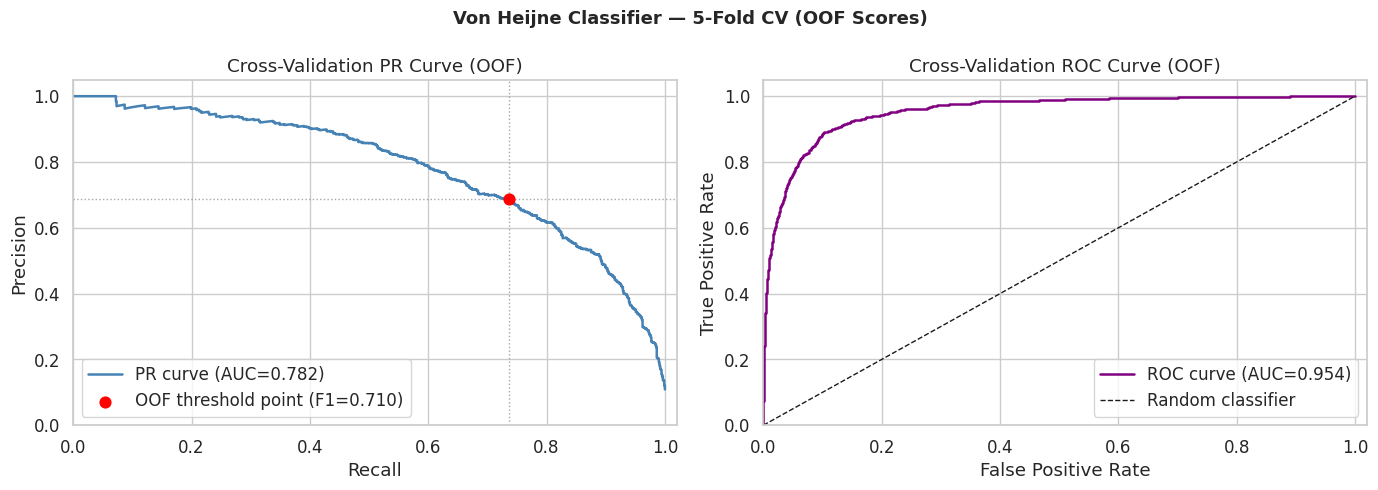

PR AUC=0.782  |  ROC AUC=0.954
Saved: figures/vh_cv_pr_roc.pdf/.png


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- PR Curve on OOF scores ---
prec_cv, rec_cv, _ = precision_recall_curve(oof_labels, oof_scores)
pr_auc = auc(rec_cv, prec_cv)

ax = axes[0]
ax.plot(rec_cv, prec_cv, color='steelblue', linewidth=1.8,
        label=f'PR curve (AUC={pr_auc:.3f})')
ax.axvline(cv_metrics['Recall'], color='gray', linestyle=':', linewidth=1, alpha=0.7)
ax.axhline(cv_metrics['Precision'], color='gray', linestyle=':', linewidth=1, alpha=0.7)
ax.scatter([cv_metrics['Recall']], [cv_metrics['Precision']],
           color='red', zorder=5, s=60,
           label=f'OOF threshold point (F1={cv_metrics["F1"]:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Cross-Validation PR Curve (OOF)')
ax.legend()
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.05)

# --- ROC Curve on OOF scores ---
fpr_cv, tpr_cv, _ = roc_curve(oof_labels, oof_scores)
roc_auc = auc(fpr_cv, tpr_cv)

ax2 = axes[1]
ax2.plot(fpr_cv, tpr_cv, color='purple', linewidth=1.8,
         label=f'ROC curve (AUC={roc_auc:.3f})')
ax2.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('Cross-Validation ROC Curve (OOF)')
ax2.legend()
ax2.set_xlim(0, 1.02)
ax2.set_ylim(0, 1.05)

plt.suptitle('Von Heijne Classifier — 5-Fold CV (OOF Scores)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/vh_cv_pr_roc.pdf', bbox_inches='tight')
plt.savefig('figures/vh_cv_pr_roc.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'PR AUC={pr_auc:.3f}  |  ROC AUC={roc_auc:.3f}')
print('Saved: figures/vh_cv_pr_roc.pdf/.png')

---
## Cell 9 — PSWM heatmap (trained on full training set)

Retrain the PSWM on **all** training positives, then visualise the log-odds weights
as a heatmap. Red = enriched vs SwissProt background, Blue = depleted.

PSWM trained on 873 positive windows


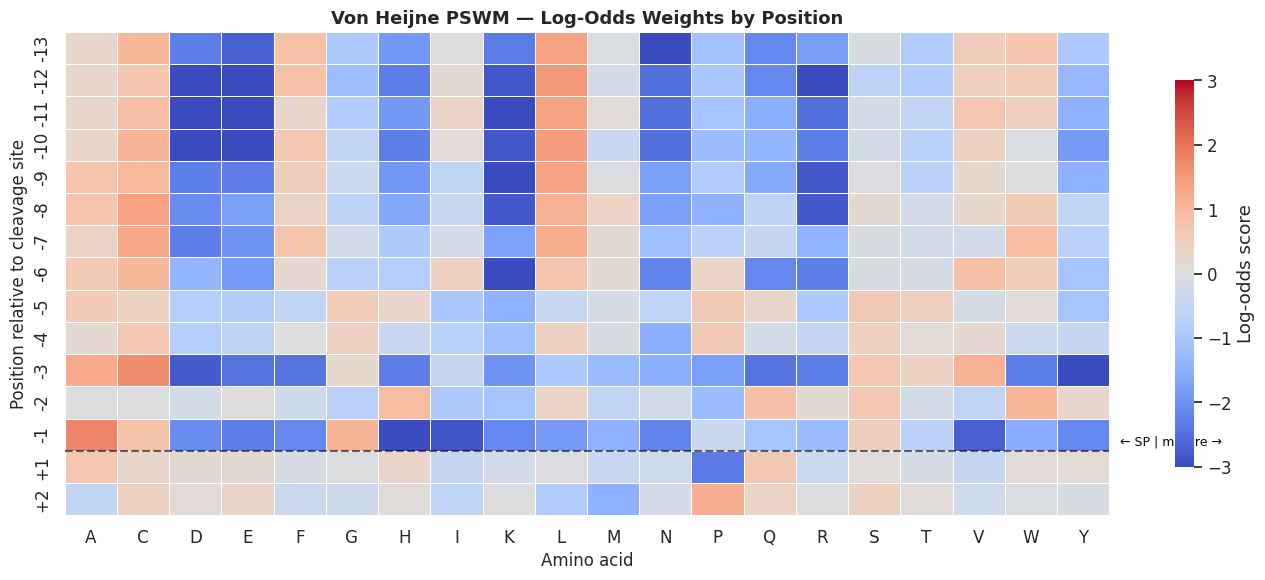

Saved: figures/vh_pswm_heatmap.pdf/.png


In [21]:
# Train on full training set
pswm_full, n_full = build_pswm(df_train)
print(f'PSWM trained on {n_full} positive windows')

# Build DataFrame for heatmap
# Rows = positions (-13 to +2), Cols = amino acids
pos_labels = [str(i) for i in range(-WINDOW_BEFORE, 0)] + ['+1', '+2']
pswm_df = pd.DataFrame(
    pswm_full,
    index=pos_labels,
    columns=AA_LIST
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    pswm_df,
    cmap='coolwarm',
    center=0,
    vmin=-3, vmax=3,
    linewidths=0.4,
    ax=ax,
    cbar_kws={'label': 'Log-odds score', 'shrink': 0.8}
)
ax.set_xlabel('Amino acid', fontsize=12)
ax.set_ylabel('Position relative to cleavage site', fontsize=12)
ax.set_title('Von Heijne PSWM — Log-Odds Weights by Position', fontsize=13, fontweight='bold')

# Draw vertical line separating SP (neg positions) from mature protein (pos)
ax.axvline(x=0, color='black', linewidth=0, alpha=0)  # spacer
ax.axhline(y=WINDOW_BEFORE, color='black', linewidth=1.5, linestyle='--', alpha=0.6)
ax.text(len(AA_LIST) + 0.2, WINDOW_BEFORE - 0.3, '← SP | mature →',
        fontsize=9, va='center', ha='left', color='black')

plt.tight_layout()
plt.savefig('figures/vh_pswm_heatmap.pdf', bbox_inches='tight')
plt.savefig('figures/vh_pswm_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/vh_pswm_heatmap.pdf/.png')

---
## Cell 10 — Blind benchmark evaluation

Apply the full PSWM (trained on all training data) to the benchmark set
using the average threshold from cross-validation.
This is the **final unbiased performance estimate** — the benchmark set
was never seen during training or threshold selection.

In [22]:
# Score all benchmark sequences
bench_scores = np.array([
    score_sequence(row['Sequence'], pswm_full)
    for _, row in df_bench.iterrows()
])
bench_labels = df_bench['label'].to_numpy()

# Apply the ONE threshold chosen from pooled OOF training predictions
bench_preds = (bench_scores >= best_threshold).astype(int)

bench_metrics = {
    'Accuracy'  : accuracy_score(bench_labels, bench_preds),
    'Precision' : precision_score(bench_labels, bench_preds, zero_division=0),
    'Recall'    : recall_score(bench_labels, bench_preds, zero_division=0),
    'F1'        : f1_score(bench_labels, bench_preds, zero_division=0),
    'MCC'       : matthews_corrcoef(bench_labels, bench_preds),
}

print(f'Benchmark Results (OOF-selected threshold = {best_threshold:.3f})')
print('-' * 52)
for metric, val in bench_metrics.items():
    print(f'  {metric:<12} : {val:.3f}')

# PR and ROC on benchmark scores
prec_b, rec_b, _ = precision_recall_curve(bench_labels, bench_scores)
fpr_b,  tpr_b, _ = roc_curve(bench_labels, bench_scores)

print(f'\n  PR AUC        : {auc(rec_b, prec_b):.3f}')
print(f'  ROC AUC       : {auc(fpr_b, tpr_b):.3f}')

Benchmark Results (OOF-selected threshold = 6.339)
----------------------------------------------------
  Accuracy     : 0.922
  Precision    : 0.625
  Recall       : 0.717
  F1           : 0.668
  MCC          : 0.626

  PR AUC        : 0.761
  ROC AUC       : 0.955


---
## Cell 11 — Benchmark confusion matrix

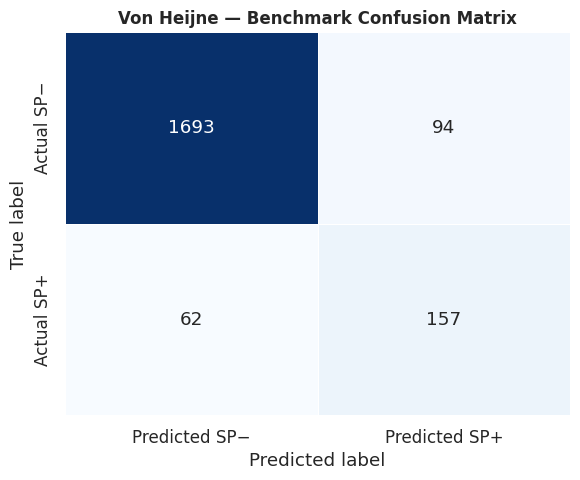

TP=157  FP=94  TN=1693  FN=62
Saved: figures/vh_benchmark_confusion.pdf/.png


In [23]:
cm = confusion_matrix(bench_labels, bench_preds)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted SP−', 'Predicted SP+'],
    yticklabels=['Actual SP−', 'Actual SP+'],
    ax=ax, linewidths=0.5, cbar=False
)
ax.set_title('Von Heijne — Benchmark Confusion Matrix', fontsize=12, fontweight='bold')
ax.set_ylabel('True label')
ax.set_xlabel('Predicted label')

plt.tight_layout()
plt.savefig('figures/vh_benchmark_confusion.pdf', bbox_inches='tight')
plt.savefig('figures/vh_benchmark_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'TP={tp}  FP={fp}  TN={tn}  FN={fn}')
print('Saved: figures/vh_benchmark_confusion.pdf/.png')

---
## Cell 12 — Final Summary

In [25]:
sep = '=' * 62
print(sep)
print('  VON HEIJNE CLASSIFIER SUMMARY — LB2 Group 7')
print(sep)
print()
print('  Model parameters')
print(f'    Window size        : {WINDOW_SIZE} positions (-{WINDOW_BEFORE} to +{WINDOW_AFTER})')
print(f'    Pseudocount        : 1.0')
print(f'    Background         : SwissProt amino acid frequencies')
print(f'    Cleavage search    : positions {MIN_CLEAVAGE}–{MAX_CLEAVAGE}')
print(f'    Training positives : {n_full}')
print(f'    OOF threshold      : {best_threshold:.3f}')
print(f'    Threshold          : selected from pooled OOF training scores, applied unchanged to benchmark')
print()
print(f'  {"Metric":<14} {"5-fold CV":>10} {"Benchmark":>12}')
print('  ' + '-' * 40)
for metric in ['Accuracy', 'Precision', 'Recall', 'F1', 'MCC']:
    cv_val = cv_metrics[metric]
    bm_val = bench_metrics[metric]
    print(f'  {metric:<14} {cv_val:>10.3f} {bm_val:>12.3f}')
print()
print('  Key note')
print('    Sequences were restricted to the filtered non-redundant set')
print('    before training and evaluation (Step 2).')
print()
print('  Output figures')
for f in sorted(os.listdir('figures')):
    if f.startswith('vh_'):
        print(f'    figures/{f}')
print()
print(sep)

  VON HEIJNE CLASSIFIER SUMMARY — LB2 Group 7

  Model parameters
    Window size        : 15 positions (-13 to +2)
    Pseudocount        : 1.0
    Background         : SwissProt amino acid frequencies
    Cleavage search    : positions 15–100
    Training positives : 873
    OOF threshold      : 6.339
    Threshold          : selected from pooled OOF training scores, applied unchanged to benchmark

  Metric          5-fold CV    Benchmark
  ----------------------------------------
  Accuracy            0.935        0.922
  Precision           0.686        0.625
  Recall              0.736        0.717
  F1                  0.710        0.668
  MCC                 0.674        0.626

  Key note
    Sequences were restricted to the filtered non-redundant set
    before training and evaluation (Step 2).

  Output figures
    figures/vh_benchmark_confusion.pdf
    figures/vh_benchmark_confusion.png
    figures/vh_cv_pr_roc.pdf
    figures/vh_cv_pr_roc.png
    figures/vh_pswm_heatmap.pdf
